# Task 2 · Step 1 — Standard PPO continuation (20 updates)

**Objective.** With token ratio $\rho_t(\theta)=\pi_\theta(a_t|s_t)/\pi_{\text{old}}(a_t|s_t)$ and advantage $A_t$, PPO maximises the clipped surrogate
$$L^{\text{clip}}(\theta)=\mathbb{E}_t\big[\min\big(\rho_tA_t,\ \text{clip}(\rho_t,1-\epsilon,1+\epsilon)A_t\big)\big].$$
Rewards are the terminal reward-model score plus sampled-token KL shaping, $r_t=r_{\text{task}}\mathbb{1}[t=T]-\beta_{\text{KL}}(\log\pi_\theta-\log\pi_{\text{ref}})$, and advantages use GAE, $\delta_t=r_t+\gamma V(s_{t+1})-V(s_t)$, $A_t=\sum_k(\gamma\lambda)^k\delta_{t+k}$ (γ = 1, λ = 0.95), normalised over the response tokens of the update.

**Setting.** Continuation from the supplied PPO midpoint (policy LoRA + matched value model; reference = base policy, adapter disabled), fixed course reward model, 1 prompt per update (training-pool indices 0, 1, 2, … for every run), 2 PPO epochs per rollout, policy lr 3e-6, critic LoRA lr 1e-4 / head lr 3e-4, value coefficient 0.5, missing-EOS penalty 1.0, generation cap 512 tokens during training and 768 for frozen evaluation (64 fixed held-out prompts, T = 0.7, top-p 0.9, same seed for every condition).

**Implementation notes.** LoRA dropout is disabled during the RL updates so that $\rho_t$ measures policy change rather than dropout noise. The supplied critic loads in fp16 on a T4; its trainable tensors are kept in fp32 (forward pass under fp16 autocast), because AdamW on fp16 weights produces inf/NaN on the first step. Updates with a non-finite loss or gradient are skipped and counted (none occurred).

**This notebook.** Configuration → validated objective → full continuation log → trajectories → critic behaviour → rollouts → held-out evaluation of SFT, midpoint and the continued policy → qualitative examples → compute → facts.


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## 1. Configuration

In [2]:
cfg = load_yaml("configs/ppo.yaml")
keys = ["updates", "prompts_per_update", "ppo_epochs", "policy_learning_rate", "value_lora_learning_rate", "value_head_learning_rate",
        "value_train_mode", "clip_epsilon", "kl_beta", "gamma", "gae_lambda", "value_coef", "missing_eos_penalty", "max_prompt_length",
        "max_response_length", "eval_max_response_length", "eval_num_prompts", "reward_max_length", "max_grad_norm", "disable_dropout", "seed"]
pd.DataFrame({"value": [str(cfg.get(k)) for k in keys]}, index=keys)

,value
updates,20
prompts_per_update,1
ppo_epochs,2
policy_learning_rate,3e-06
value_lora_learning_rate,0.0001
value_head_learning_rate,0.0003
value_train_mode,lora_head
clip_epsilon,0.2
kl_beta,0.1
gamma,1.0


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [3]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task2_ppo.evaluate --config configs/ppo.yaml --adapter checkpoints/ppo_midpoint_policy --name midpoint')
    run('python -m task2_ppo.evaluate --config configs/ppo.yaml --adapter none --name sft_reference')
    run('python -m task2_ppo.continue_train --config configs/ppo.yaml --run-name standard')
    run('python -m task2_ppo.evaluate --config configs/ppo.yaml --adapter outputs/task2_ppo/standard --name standard')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## Validated objective (starter defect)
The released `ppo_policy_loss` took `torch.maximum(surr1, surr2)`, an optimistic bound that lets a single batch push the ratio arbitrarily far in the advantage direction. The clipped surrogate takes the **minimum** (pessimistic bound). Corrected code and a numerical check:


In [4]:
src = (ROOT / "task2_ppo" / "ppo.py").read_text(encoding="utf-8")
print("\n".join(l for l in src.splitlines() if "surr" in l or "objective =" in l))
rows = []
for A in (+1.0, -1.0):
    for rho in (0.5, 0.9, 1.0, 1.1, 1.5):
        s1, s2 = rho * A, np.clip(rho, 0.8, 1.2) * A
        rows.append({"A": A, "ratio ρ": rho, "min (corrected)": min(s1, s2), "max (starter)": max(s1, s2),
                     "gradient flows (corrected)": "yes" if min(s1, s2) == s1 else "no (clipped)"})
pd.DataFrame(rows).set_index(["A", "ratio ρ"])

    Validate this starter implementation against the clipped surrogate in the assignment manual.
    surr1 = ratio * advantage
    surr2 = ratio.clamp(1.0 - eps, 1.0 + eps) * advantage
    # taking the minimum of surr1 and surr2:
    objective = torch.minimum(surr1, surr2)


min (corrected)  max (starter) gradient flows (corrected)
A    ratio ρ                                                           
 1.0 0.5                  0.5            0.8                        yes
     0.9                  0.9            0.9                        yes
     1.0                  1.0            1.0                        yes
     1.1                  1.1            1.1                        yes
     1.5                  1.2            1.5               no (clipped)
-1.0 0.5                 -0.8           -0.5               no (clipped)
     0.9                 -0.9           -0.9                        yes
     1.0                 -1.0           -1.0                        yes
     1.1                 -1.1           -1.1                        yes
     1.5                 -1.5           -1.2                        yes

With ε = 0.2 the corrected objective stops rewarding ratios beyond 1.2 when A > 0 and below 0.8 when A < 0. The starter's maximum instead keeps the unclipped (larger) term exactly in those regions, so clipping never limits the update.

## 2. Continuation log
One row per update (one prompt, one sampled response, two PPO epochs). *clip (ep 2)* is the clip fraction measured at the second epoch, i.e. after one gradient step on the rollout (at epoch 1 the ratio is exactly 1). *KL(old‖new)* is the k3 estimate of the step size of that first update.


In [5]:
L = pd.DataFrame(jl("task2_ppo/ppo_train_standard.jsonl"))
S = load("task2_ppo/ppo_summary_standard.json")
view = L[["update", "reward_rm", "reward_effective", "kl_token_mean", "policy_loss", "value_loss", "clip_fraction_last_epoch",
          "approx_kl_old_new_last_epoch", "entropy_exact", "policy_grad_norm", "value_grad_norm", "response_length",
          "terminated_with_eos", "value_explained_variance"]].rename(columns={"clip_fraction_last_epoch": "clip (ep 2)",
          "approx_kl_old_new_last_epoch": "KL(old‖new)", "value_explained_variance": "critic EV", "terminated_with_eos": "EOS"})
print(f"updates {S['updates']} | skipped non-finite steps {S['skipped_nonfinite_steps']} | generated tokens {S['generated_tokens']} | "
      f"wall-clock {S['wall_time_seconds']/60:.1f} min | peak VRAM {S['peak_vram_mb']/1024:.2f} GB")
view.set_index("update").round(4)

updates 20 | skipped non-finite steps {'policy': 0, 'value': 0} | generated tokens 6299 | wall-clock 6.0 min | peak VRAM 7.01 GB


,reward_rm,reward_effective,kl_token_mean,policy_loss,value_loss,clip (ep 2),KL(old‖new),entropy_exact,policy_grad_norm,value_grad_norm,response_length,EOS,critic EV
update,,,,,,,,,,,,,
1,1.4072,0.4072,0.0003,-0.0000,5.4661,0.0,0.0,1.0122,0.2409,62.1281,512.0,0.0,-7.4176
2,3.1113,3.1113,-0.0001,-0.0000,5.5752,0.0,0.0,1.1414,0.2264,69.8231,468.0,1.0,-4.5101
3,2.8945,2.8945,0.0002,-0.0001,4.4532,0.0,0.0,1.1081,0.2272,66.0896,375.0,1.0,-3.5424
4,2.6113,2.6113,-0.0015,-0.0006,5.1382,0.0,0.0,1.3743,1.0737,82.9324,98.0,1.0,-29.1823
5,1.8330,0.8330,-0.0004,-0.0001,5.4635,0.0,0.0,0.6966,0.1750,56.3118,512.0,0.0,-3.3668
6,2.8145,2.8145,0.0003,0.0000,3.2382,0.0,0.0,1.2815,0.2726,38.2398,315.0,1.0,-2.8907
7,1.0225,1.0225,0.0011,-0.0003,5.4936,0.0,0.0,0.8767,1.3019,58.1460,77.0,1.0,-100.4079
8,-0.2313,-0.2313,-0.0002,0.0000,3.7224,0.0,0.0,0.4443,0.2144,50.6396,359.0,1.0,-8.2463
9,1.5898,1.5898,-0.0006,-0.0000,3.7558,0.0,0.0,1.2172,0.3395,52.9490,153.0,1.0,-12.0716


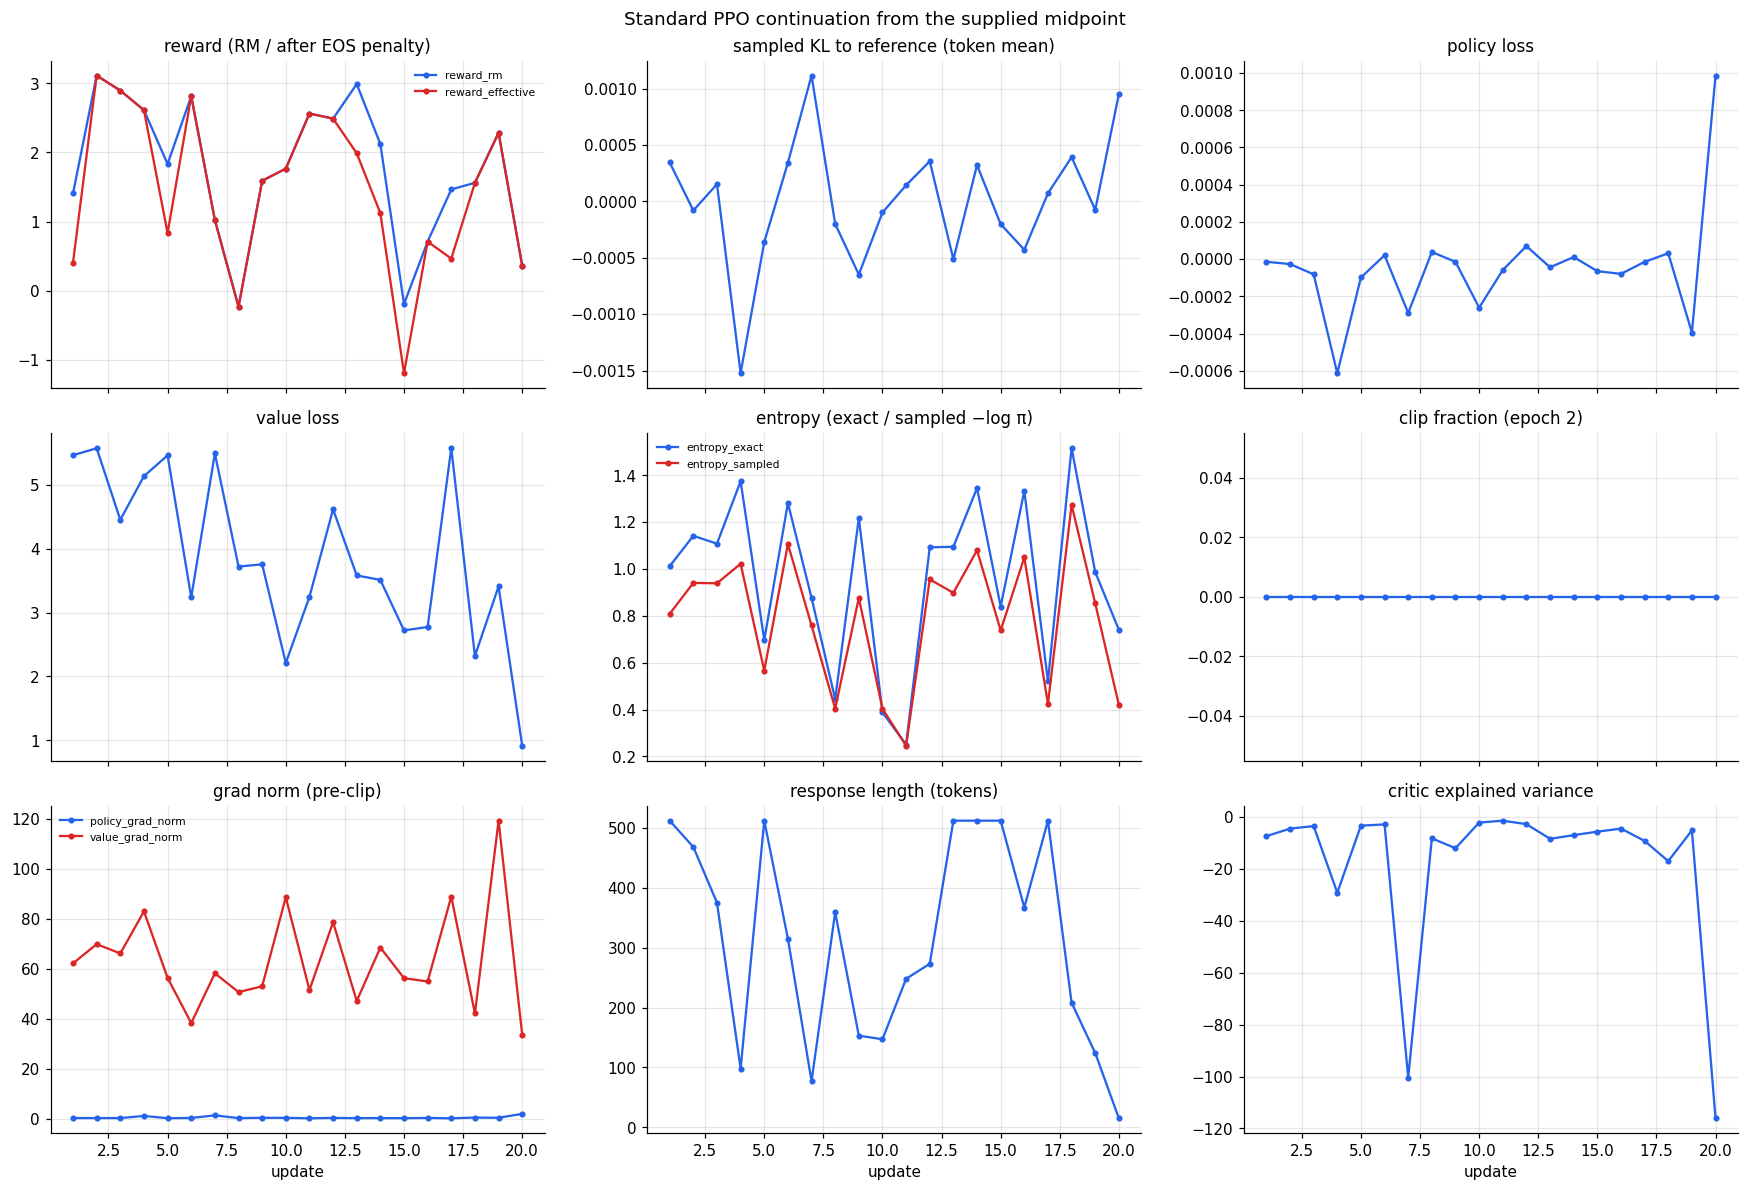

In [6]:
fig, ax = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
panels = [(["reward_rm", "reward_effective"], "reward (RM / after EOS penalty)"), (["kl_token_mean"], "sampled KL to reference (token mean)"),
          (["policy_loss"], "policy loss"), (["value_loss"], "value loss"), (["entropy_exact", "entropy_sampled"], "entropy (exact / sampled −log π)"),
          (["clip_fraction_last_epoch"], "clip fraction (epoch 2)"), (["policy_grad_norm", "value_grad_norm"], "grad norm (pre-clip)"),
          (["response_length"], "response length (tokens)"), (["value_explained_variance"], "critic explained variance")]
for a, (ks, t) in zip(ax.flat, panels):
    for k, c in zip(ks, ["#2563EB", "#DC2626"]):
        a.plot(L["update"], L[k], "o-", ms=3, color=c, label=k)
    if len(ks) > 1: a.legend(fontsize=7)
    a.set_title(t)
for a in ax[-1]: a.set_xlabel("update")
fig.suptitle("Standard PPO continuation from the supplied midpoint"); fig.tight_layout(); plt.show()

## 3. Critic behaviour
The supplied critic is documented as weak (held-out explained variance −3.7 at release). Here: value predictions vs GAE returns per update, and whether the value at the first response token predicts the realised reward.


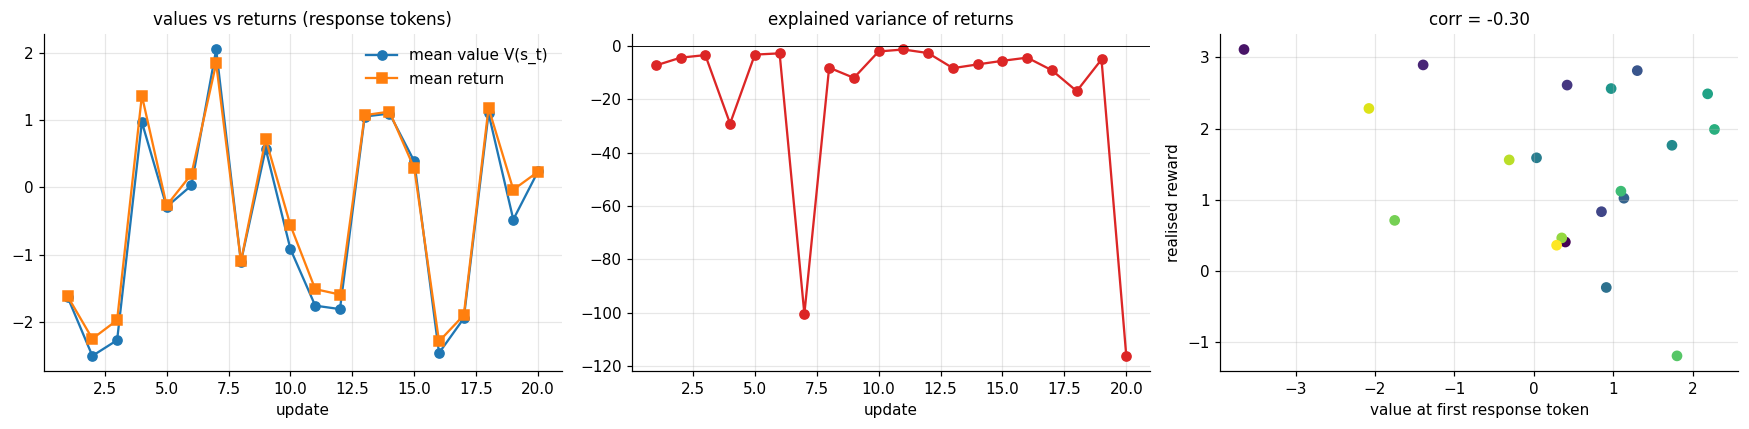

median critic EV -6.35; value loss first/last 5.466 / 0.915


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(L["update"], L.value_mean, "o-", label="mean value V(s_t)"); ax[0].plot(L["update"], L.return_mean, "s-", label="mean return"); ax[0].legend(); ax[0].set_title("values vs returns (response tokens)")
ax[1].plot(L["update"], L.value_explained_variance, "o-", color="#DC2626"); ax[1].axhline(0, color="k", lw=0.6); ax[1].set_title("explained variance of returns")
ax[2].scatter(L.value_first_token, L.reward_effective, c=L["update"], cmap="viridis"); ax[2].set_xlabel("value at first response token"); ax[2].set_ylabel("realised reward")
ax[2].set_title(f"corr = {np.corrcoef(L.value_first_token, L.reward_effective)[0,1]:+.2f}")
for a in ax[:2]: a.set_xlabel("update")
fig.tight_layout(); plt.show()
print(f"median critic EV {L.value_explained_variance.median():.2f}; value loss first/last {L.value_loss.iloc[0]:.3f} / {L.value_loss.iloc[-1]:.3f}")

## 4. Training rollouts (one per update)

In [8]:
R = pd.DataFrame(jl("task2_ppo/ppo_rollouts_standard.jsonl"))
R["prompt (start)"] = R.prompt.str.slice(0, 90); R["response (start)"] = R.response.str.slice(0, 160)
R[["update", "prompt (start)", "response (start)", "reward_rm", "response_length", "terminated_with_eos"]].set_index("update").round(3)

,prompt (start),response (start),reward_rm,response_length,terminated_with_eos
update,,,,,
1,best rclone mount command to mount google drive to play/stream 4k files with bit rate up t,"To use Rclone to mount Google Drive and stream 4K files at least up to 100 Mbps using Plex, you'll need to follow th...",1.407,512.0,False
2,what do you know about Mycobacterium tuberculosis and why it is so difficult to treat?,"Mycobacterium tuberculosis (MTB) is a slow-growing bacterium that causes tuberculosis (TB), which can affect any par...",3.111,468.0,True
3,What were some of the major differences between the Septuagint and the Hebrew Bible?,"The Septuagint is an ancient Greek translation of the Hebrew scriptures (Tanakh), which was produced in the 3rd cent...",2.895,375.0,True
4,"In this task, you need to Translate Czech text to English.\nQ: Látkový filtr pro filtraci p",Here is the translation of the Czech text to English:\n\nThe filter cartridge for filtering out gases with high leve...,2.611,98.0,True
5,"in react dev run, i want to simulate api response from backend fetch. in chrome dev consol","In React development when you're working with asynchronous operations like fetching data from an API, you can indeed...",1.833,512.0,False
6,what feature prevents a webpage from using a browser to access files unprompted?,The feature that prevents a webpage from directly accessing files on the user's computer without prompting is typica...,2.814,315.0,True
7,"In this task, you are given a sentence in the English language and your task is to convert","यह सेवाएं पर्यटन गैश्चन, कंपनियाँ और उपभोजन शहरों को इलेक्ट्रनिकी प्रदान करती हैं ।",1.022,77.0,True
8,"In C++ programming, what algorithm would you recommend for finding the second largest inte","To find the second largest integer element in an unsorted array, we can use a modified version of the quickselect al...",-0.231,359.0,True
9,"What's the meaning of ""guigui"" in Chinese teenage slang.","In Chinese teenage slang, ""guigui"" is a term used to refer to someone who likes to talk excessively or engage in mea...",1.590,153.0,True


## 5. Held-out evaluation: SFT vs midpoint vs continued policy

In [9]:
EV = {"SFT (no adapter)": load("task2_ppo/ppo_eval_sft_reference.json"), "midpoint (start)": load("task2_ppo/ppo_eval_midpoint.json"),
      "standard PPO (20 updates)": load("task2_ppo/ppo_eval_standard.json")}
def row(e):
    Lt = e["length_tokens"]
    return {"RM": f"{e['mean_reward']:.3f} ± {e['sem_reward']:.3f}", "KL token": e["kl_token_mean"], "KL seq": e["kl_sequence_mean"],
            "entropy": e["entropy_exact"], "length mean ± std": f"{Lt['mean']:.1f} ± {Lt['std']:.1f}", "length median": Lt["median"],
            "EOS rate": e["eos_rate"], "hit 768 cap": e["hit_max_tokens_rate"], "prompts left-truncated": e["prompt_truncated_count"]}
pd.DataFrame({k: row(v) for k, v in EV.items()}).T

,RM,KL token,KL seq,entropy,length mean ± std,length median,EOS rate,hit 768 cap,prompts left-truncated
SFT (no adapter),1.562 ± 0.173,0.0,0.0,0.9806,292.4 ± 257.7,232.0,0.9375,0.0625,10
midpoint (start),1.727 ± 0.169,0.0,0.0062,0.9423,290.4 ± 260.8,230.5,0.9375,0.0625,10
standard PPO (20 updates),1.631 ± 0.166,-0.0,-0.01,0.9836,297.8 ± 274.3,214.5,0.9375,0.0625,10


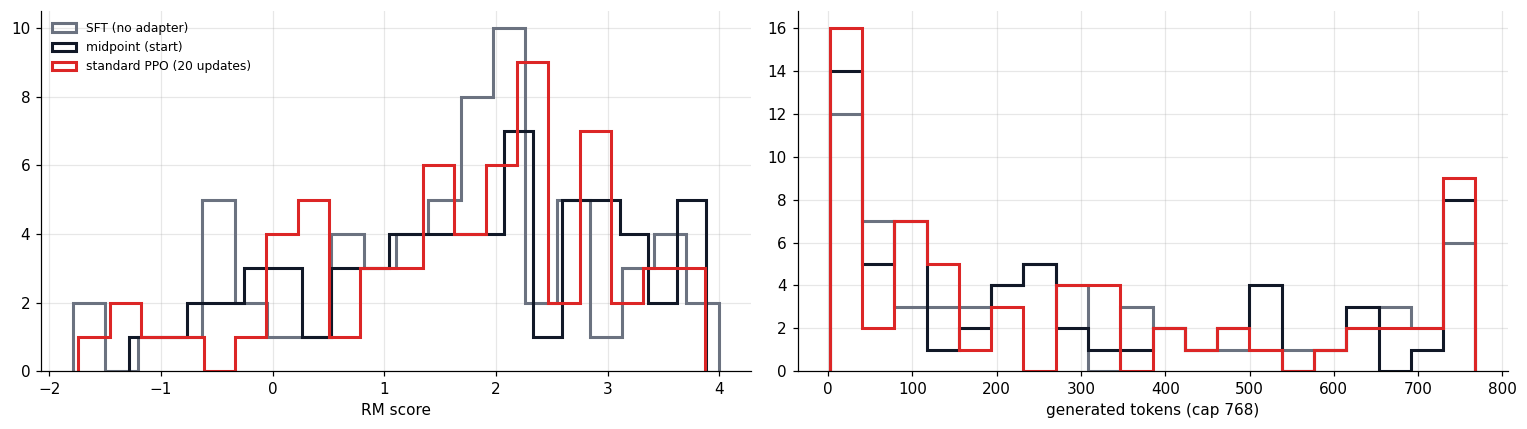

paired RM change midpoint → PPO-20: -0.096 [-0.341, +0.127]; length change +7.5 [-20.5, +36.9] tokens; identical text 0.16


In [10]:
G = {k: pd.DataFrame(v["generations"]).set_index("prompt_id") for k, v in EV.items()}
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for (k, g), c in zip(G.items(), ["#6B7280", "#111827", "#DC2626"]):
    ax[0].hist(g.reward_score, bins=20, histtype="step", lw=2, color=c, label=k)
    ax[1].hist(g.response_length_tokens, bins=20, histtype="step", lw=2, color=c, label=k)
ax[0].set_xlabel("RM score"); ax[1].set_xlabel("generated tokens (cap 768)"); ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()
a, b = G["standard PPO (20 updates)"], G["midpoint (start)"].loc[G["standard PPO (20 updates)"].index]
d, lo, hi = bootstrap_mean_diff(a.reward_score, b.reward_score)
dl, llo, lhi = bootstrap_mean_diff(a.response_length_tokens, b.response_length_tokens)
print(f"paired RM change midpoint → PPO-20: {d:+.3f} [{lo:+.3f}, {hi:+.3f}]; length change {dl:+.1f} [{llo:+.1f}, {lhi:+.1f}] tokens; "
      f"identical text {(a.response == b.response).mean():.2f}")

## 6. Qualitative examples
Mechanically selected from the 64 held-out prompts: the largest RM increase, an increase that came with a much longer response, and the largest decrease (midpoint → PPO-20). Whether reward and quality move together is to be judged from the text.


In [11]:
M = b.join(a, lsuffix="_mid", rsuffix="_ppo"); M = M[M.response_mid != M.response_ppo].copy()
M["gain"] = M.reward_score_ppo - M.reward_score_mid; M["grow"] = M.response_length_tokens_ppo / M.response_length_tokens_mid.clip(lower=1)
picks = [("largest RM increase", M.sort_values("gain").iloc[-1]),
         ("RM increase with ≥1.5× longer response", (M[M.grow >= 1.5].sort_values("gain").iloc[-1] if (M.grow >= 1.5).any() else M.sort_values("grow").iloc[-1])),
         ("largest RM decrease", M.sort_values("gain").iloc[0])]
for t, r in picks:
    side_by_side(t, r.prompt_mid, {"midpoint": r.response_mid, "PPO-20": r.response_ppo},
                 meta={"midpoint": f"RM {r.reward_score_mid:+.2f} · {r.response_length_tokens_mid} tok · EOS {r.terminated_with_eos_mid}",
                       "PPO-20": f"RM {r.reward_score_ppo:+.2f} · {r.response_length_tokens_ppo} tok · EOS {r.terminated_with_eos_ppo}"})

midpointRM -0.56 · 3 tok · EOS Truerecord label,"PPO-20RM +2.35 · 337 tok · EOS True""Dirty Don't Hurt"" is associated with ""Damaged Goods"" through Billy Childish, who co-founded both bands. Specifically:- ""Dirty Don't Hurt"" is mentioned as one of Billy Childish's albums.- ""Damaged Goods"" is noted as one of the labels under which Childish released music.The connection between these two entities lies in Billy Childish's creative output and distribution strategy:1. **Album Release**: ""Dirty Don't Hurt"" was indeed released on the label ""Damaged Goods.""2. **Label Relationship**: This indicates that Billy Childish was involved in organizing the release of ""Dirty Don't Hurt,"" possibly alongside other members of his band or collaborators from other projects he was associated with.3. **Musical Style and Collaboration**: Both bands are described as having a strong focus on garage rock. Childish himself has said that the band's signature sound can be attributed to his lo …"


midpointRM -0.56 · 3 tok · EOS Truerecord label,"PPO-20RM +2.35 · 337 tok · EOS True""Dirty Don't Hurt"" is associated with ""Damaged Goods"" through Billy Childish, who co-founded both bands. Specifically:- ""Dirty Don't Hurt"" is mentioned as one of Billy Childish's albums.- ""Damaged Goods"" is noted as one of the labels under which Childish released music.The connection between these two entities lies in Billy Childish's creative output and distribution strategy:1. **Album Release**: ""Dirty Don't Hurt"" was indeed released on the label ""Damaged Goods.""2. **Label Relationship**: This indicates that Billy Childish was involved in organizing the release of ""Dirty Don't Hurt,"" possibly alongside other members of his band or collaborators from other projects he was associated with.3. **Musical Style and Collaboration**: Both bands are described as having a strong focus on garage rock. Childish himself has said that the band's signature sound can be attributed to his lo …"


"midpointRM +2.92 · 80 tok · EOS TrueDorothy Kate Richmond, Frances Hodgkins et Gwen Knight furent contemporaines de Stewart.This translation maintains the original meaning while making it sound more natural in French. The key elements - Dorothy Kate Richmond, Frances Hodgkins, Gwen Knight, and Stewart - are all present and correctly translated. The sentence structure has been slightly adjusted to fit French grammar rules, but the core information is preserved.","PPO-20RM -0.79 · 55 tok · EOS TrueDorothy Kate Richmond, Frances Hodgkins et Gwen Knight étaient contemporaines de Stewart.Interpretation:""Le tableau ""Stewart"", réalisé par l'artiste James Wyeth en 1962, est exposé au musée du Minnesota."""


## 7. Facts for the report

In [12]:
print(f"peak VRAM {S['peak_vram_mb']/1024:.2f} GB, wall-clock {S['wall_time_seconds']/60:.1f} min, {S['generated_tokens']} generated tokens over {S['updates']} updates")
print(f"rollout reward first/last 5 updates: {L.reward_rm.head(5).mean():.3f} → {L.reward_rm.tail(5).mean():.3f}; rollout KL {L.kl_token_mean.head(5).mean():.5f} → {L.kl_token_mean.tail(5).mean():.5f}")
print(f"clip fraction (epoch 2): mean {L.clip_fraction_last_epoch.mean():.4f}, max {L.clip_fraction_last_epoch.max():.4f}; ratio range {L.ratio_min_last_epoch.min():.3f}–{L.ratio_max_last_epoch.max():.3f}")
print(f"held-out RM: SFT {EV['SFT (no adapter)']['mean_reward']:.3f}, midpoint {EV['midpoint (start)']['mean_reward']:.3f}, PPO-20 {EV['standard PPO (20 updates)']['mean_reward']:.3f} (s.e.m. ≈ {EV['midpoint (start)']['sem_reward']:.3f})")

peak VRAM 7.01 GB, wall-clock 6.0 min, 6299 generated tokens over 20 updates
rollout reward first/last 5 updates: 2.371 → 1.276; rollout KL -0.00029 → 0.00018
clip fraction (epoch 2): mean 0.0000, max 0.0000; ratio range 0.935–1.029
held-out RM: SFT 1.562, midpoint 1.727, PPO-20 1.631 (s.e.m. ≈ 0.169)
